# Programación Genética (GP): Evolucionando Estructuras y Ecuaciones

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/07_programacion_genetica_gp.ipynb)

## Objetivos


- Comprender el cambio de paradigma: de optimizar parámetros (vectores) a optimizar estructuras de código (Árboles de Sintaxis Abstracta).
- Dominar el vocabulario de la Programación Genética: `PrimitiveSet`, Nodos, Hojas y Constantes Efímeras.
- Implementar **Funciones Protegidas** para garantizar la estabilidad matemática durante la evolución.
- Diagnosticar y controlar el **Bloat** (crecimiento descontrolado del código) mediante límites estáticos y presión de parsimonia.
- Resolver un problema clásico de **Regresión Simbólica**, descubriendo la ley matemática subyacente en un conjunto de datos ruidosos.



## Prerrequisitos


- Haber completado: [Introducción a DEAP: Infraestructura Evolutiva en Python](03_framework_deap_y_paralelizacion.ipynb).
- Nociones básicas de estructuras de datos en árbol.

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import random
import operator
import math
import warnings
warnings.filterwarnings('ignore')

try:
    import deap
except ImportError:
    !pip install deap
from deap import base, creator, tools, algorithms, gp

# Fijamos la semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 17.9 MB/s eta 0:00:00


## Introducción Teórica: El Salto a la Estructura



Hasta ahora, en algoritmos como GA, DE o PSO, nuestro espacio de búsqueda era un vector de números ($x \in \mathbb{R}^D$). El experto debía defir la forma de la ecuación (ej. $f(x) = ax^2 + bx + c$) y el algoritmo buscaba los mejores valores para los parámetros $[a, b, c]$.

La **Programación Genética (GP)**, popularizada por John Koza en 1992, da un paso radical: **el algoritmo decide tanto la forma de la ecuación como sus parámetros**.

Para lograr esto, los individuos ya no pueden ser listas planas de números. Deben ser programas informáticos o ecuaciones matemáticas. En GP, representamos estas ecuaciones utilizando **Árboles de Sintaxis Abstracta (AST)**.

### Anatomía de un Árbol GP


Cualquier ecuación matemática puede representarse como un árbol invertido:
*   **Nodos Internos (Funciones):** Operaciones matemáticas (`+`, `-`, `*`, `/`, `sin`, `cos`). Tienen "hijos" (argumentos).
*   **Hojas (Terminales):** Variables del problema ($x, y$) y Constantes numéricas ($3.14$, $2.0$). No tienen hijos.

Por ejemplo, la ecuación $x^2 + \sin(x)$ se representa como:
```text
      +
     / \
    *   sin
   / \    \
  x   x    x
```

## Desarrollo e Implementación


### 1. Vocabulario del GP: `PrimitiveSet` y Funciones Protegidas



Para que el algoritmo pueda construir árboles, debemos darle una caja de bloques a utilizar. En DEAP, esto se llama `PrimitiveSet`.

> ⚠️ **Criterio de Ingeniería (Funciones Protegidas):**
> Si le damos al GP el operador de división `/` y la variable $x$, eventualmente generará el árbol `x / 0` o `x / (x - x)`. Cuando intentemos evaluar ese individuo, Python lanzará un `ZeroDivisionError` y todo nuestro proceso de 3 horas crasheará por una excepción no manejada.
> En GP, **todas las funciones deben ser seguras**. Debemos envolver operaciones peligrosas (división, logaritmo, raíz cuadrada) en funciones protegidas que devuelvan un valor de contingencia (ej. $1,0$) en lugar de lanzar un error.

In [ ]:
# 1. Definimos nuestras Funciones Protegidas
def protected_div(left, right):
    """División protegida: retorna 1.0 si el denominador es muy cercano a 0."""
    if abs(right) < 1e-6:
        return 1.0
    return left / right

# Otro ejemplo solamente, no la uso para este caso
def protected_log(x):
    """Logaritmo protegido: evita log(0) y log(negativos)."""
    if abs(x) < 1e-6:
        return 0.0
    return math.log(abs(x))

# 2. Creamos el PrimitiveSet
# "MAIN" es el nombre del conjunto. arity=1 indica que nuestra ecuación tendrá 1 variable de entrada.
pset = gp.PrimitiveSet("MAIN", arity=1)
# Renombramos el argumento por defecto 'ARG0' a 'x' para que las ecuaciones sean legibles
pset.renameArguments(ARG0='x')

# 3. Añadimos los Nodos Internos (Funciones)
pset.addPrimitive(operator.add, 2) # Suma (aridad 2)
pset.addPrimitive(operator.sub, 2) # Resta (aridad 2)
pset.addPrimitive(operator.mul, 2) # Multiplicación (aridad 2)
pset.addPrimitive(protected_div, 2) # División protegida (aridad 2)
# pset.addPrimitive(protected_log, 1) # Logaritmo protegido (aridad 1)
pset.addPrimitive(math.sin, 1)     # Seno (aridad 1)
pset.addPrimitive(math.cos, 1)     # Coseno (aridad 1)

# 4. Añadimos Constantes Efímeras (ERC - Ephemeral Random Constants)
# Una ERC es una función que genera un número aleatorio cuando se crea el nodo hoja.
# Ese número quedará FIJO para ese nodo durante toda la evolución.
pset.addEphemeralConstant("rand101", lambda: round(random.uniform(-5, 5), 2))

print("PrimitiveSet configurado con éxito.")

PrimitiveSet configurado con éxito.


### 2. Generación y Visualización de Árboles



DEAP ofrece tres métodos para generar árboles aleatorios iniciales:
1.  `genFull`: Crea árboles perfectamente simétricos donde todas las hojas están a la profundidad máxima.
2.  `genGrow`: Crea árboles asimétricos. Las hojas pueden aparecer en cualquier nivel.
3.  `genHalfAndHalf`: El estándar de la industria. Genera la mitad de la población con `genFull` y la otra mitad con `genGrow`, garantizando máxima diversidad estructural.


Vemos la diferencia generando un árbol con cada método:


In [3]:
# Configuramos los tipos básicos de DEAP
for cls in ['FitnessMin', 'Individual']:
    if hasattr(creator, cls): delattr(creator, cls)

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

print("Comparativa de Métodos de Inicialización (Profundidad 1 a 3):")
for nombre, metodo in [("Full", gp.genFull), ("Grow", gp.genGrow), ("HalfAndHalf", gp.genHalfAndHalf)]:
    random.seed(42)
    expr = metodo(pset=pset, min_=1, max_=3)
    arbol = creator.Individual(expr)
    print(f"  {nombre:<12} -> Nodos: {len(arbol):<2} | Profundidad: {arbol.height} | Expr: {str(arbol)[:50]}...")

# Registramos el estándar para el resto del notebook
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)

Comparativa de Métodos de Inicialización (Profundidad 1 a 3):
  Full         -> Nodos: 11 | Profundidad: 3 | Expr: add(add(cos(-2.55), sub(x, x)), sin(protected_div(...
  Grow         -> Nodos: 3  | Profundidad: 1 | Expr: add(-2.55, x)...
  HalfAndHalf  -> Nodos: 2  | Profundidad: 1 | Expr: cos(-2.55)...


NOTA: las ecuaciones generadas tienen **Formato Lisp/Prefijo**.

Construimos una pequeña función de layout jerárquico nativa usando `networkx`, así podemos visualizar el árbol.

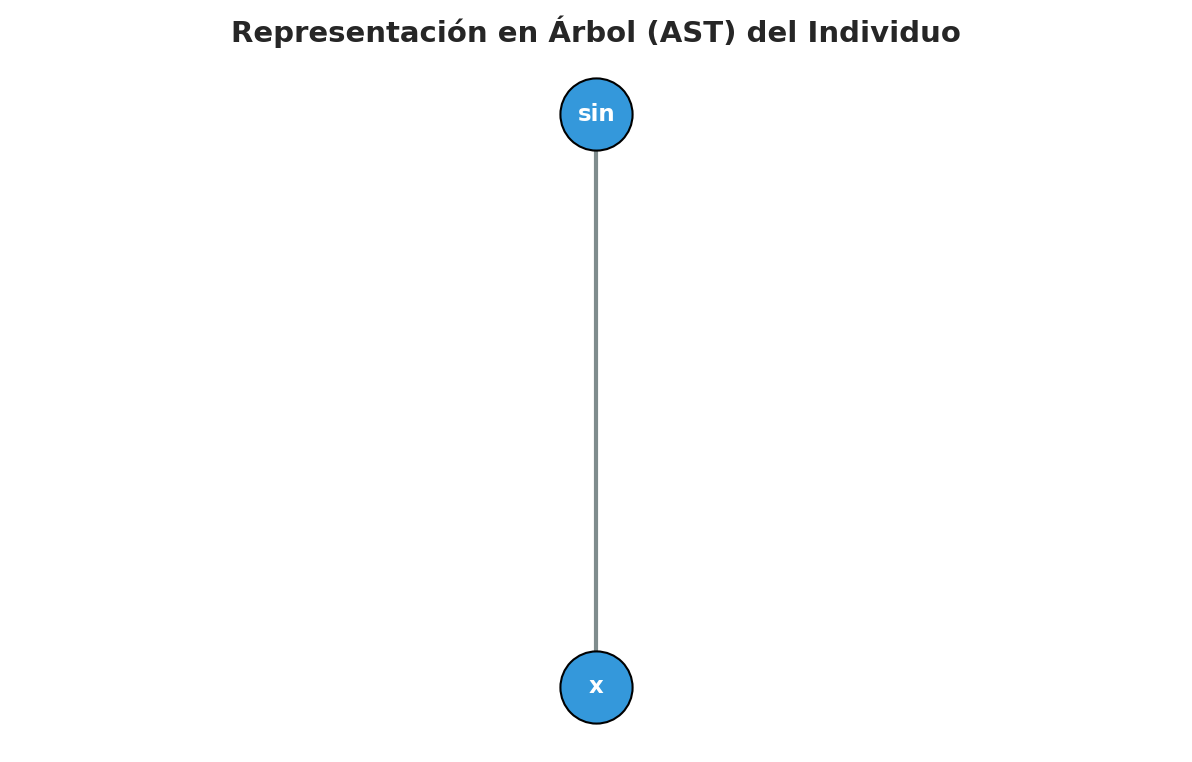

In [4]:
import networkx as nx

def hierarchy_pos(G, root=0, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """Calcula las coordenadas (x,y) para dibujar un árbol jerárquico perfecto."""
    pos = {root: (xcenter, vert_loc)}
    neighbors = list(G.neighbors(root))
    if not neighbors: return pos
    dx = width / len(neighbors)
    nextx = xcenter - width/2 - dx/2
    for neighbor in neighbors:
        nextx += dx
        pos.update(hierarchy_pos(G, neighbor, width=dx, vert_gap=vert_gap,
                                 vert_loc=vert_loc-vert_gap, xcenter=nextx))
    return pos

def dibujar_arbol_gp(individuo):
    nodes, edges, labels = gp.graph(individuo)
    g = nx.DiGraph() # Grafo dirigido para mantener la jerarquía
    g.add_nodes_from(nodes)
    g.add_edges_from(edges)

    pos = hierarchy_pos(g, root=0)

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_edges(g, pos, width=2, edge_color='#7f8c8d', arrows=False)
    nx.draw_networkx_nodes(g, pos, node_color='#3498db', node_size=1200, edgecolors='black')
    nx.draw_networkx_labels(g, pos, labels, font_size=11, font_weight='bold', font_color='white')
    plt.title("Representación en Árbol (AST) del Individuo", fontsize=14)
    plt.axis('off')
    plt.show()

random.seed(15)
arbol_ejemplo = toolbox.individual()
dibujar_arbol_gp(arbol_ejemplo)

Si se prefiere en texto, va alternativa también. Así se usa a demanda en las aplicaciones propias:

In [5]:
# --- Función auxiliar para imprimir el árbol de texto ---
def print_tree_text_recursive(current_node, depth, edges, labels):
    """Imprime el árbol de forma recursiva con indentación."""
    indent = "  " * depth
    print(f"{indent}- {labels[current_node]}")

    # Encontrar hijos del nodo actual
    children = [child for parent, child in edges if parent == current_node]
    for child in children:
        print_tree_text_recursive(child, depth + 1, edges, labels)

print("Estructura de nodos jerárquica: ")
nodes, edges, labels = gp.graph(arbol_ejemplo)

# Determinar el nodo raíz (el que no es hijo de ningún otro nodo)
all_children = {child for _, child in edges}
root_nodes = [node for node in nodes if node not in all_children]

if root_nodes:
    root = root_nodes[0]
    print_tree_text_recursive(root, 0, edges, labels)
elif nodes: # Si hay al menos un nodo, se imprime como raíz (caso de un solo terminal)
    print_tree_text_recursive(nodes[0], 0, edges, labels)
else: # Árbol vacío, no debería ocurrir con genHalfAndHalf
    print("  (Árbol vacío)")

Estructura de nodos jerárquica: 
- sin
  - x


### 3. Operadores Genéticos Estructurales



En GP, los operadores no cruzan números, cruzan **ramas de código**.

*   **Cruce de Subárboles (`cxOnePoint`):** Elige un nodo al azar en el Padre 1 y un nodo al azar en el Padre 2. Intercambia los subárboles que cuelgan de esos nodos.
*   **Mutación Uniforme (`mutUniform`):** Elige un nodo al azar y reemplaza todo su subárbol por uno nuevo generado aleatoriamente.
*   **Mutación de Nodo (`mutNodeReplacement`):** Cambia un nodo por otro de la misma aridad (ej. cambia un `+` por un `*`, o una `x` por un `3.14`).



### 4. El Enemigo Silencioso: El *Bloat* y la Parsimonia


Si se cruzan dos árboles grandes, el hijo puede ser aún más grande. Generación tras generación, los árboles tienden a crecer infinitamente acumulando "código basura" (intrones), como $x + 0$, $x \cdot 1$, o $x - x$.

Este fenómeno se llama **Bloat**. Destruye la interpretabilidad de la ecuación (el individuo se vuelve ilegible) y se pierde generalización, además consume toda la memoria RAM. Por lo tanto, controlar el *bloat* es tan importante como maximizar el fitness.

**Soluciones de Ingeniería:**
1.  **Límites Estáticos:** Usar el decorador `staticLimit` de DEAP para rechazar cualquier hijo que supere una profundidad máxima (ej. 17 niveles).
2.  **Presión de Parsimonia (Parsimony Pressure):** En la función de fitness, penalizamos a los individuos restándoles puntos por cada nodo extra que tengan.

*Equivalente a las restricciones duras y blandas ya abordadas...*

## Caso Práctico: Regresión Simbólica Clásica



Ponemos a prueba nuestro GP. Generamos un dataset sintético basado en un polinomio cúbico con ruido inyectado. El objetivo del GP es "redescubrir" la ley matemática subyacente solo observando los datos.

**Función Oculta:** $y = x^3 - 2x^2 + x$


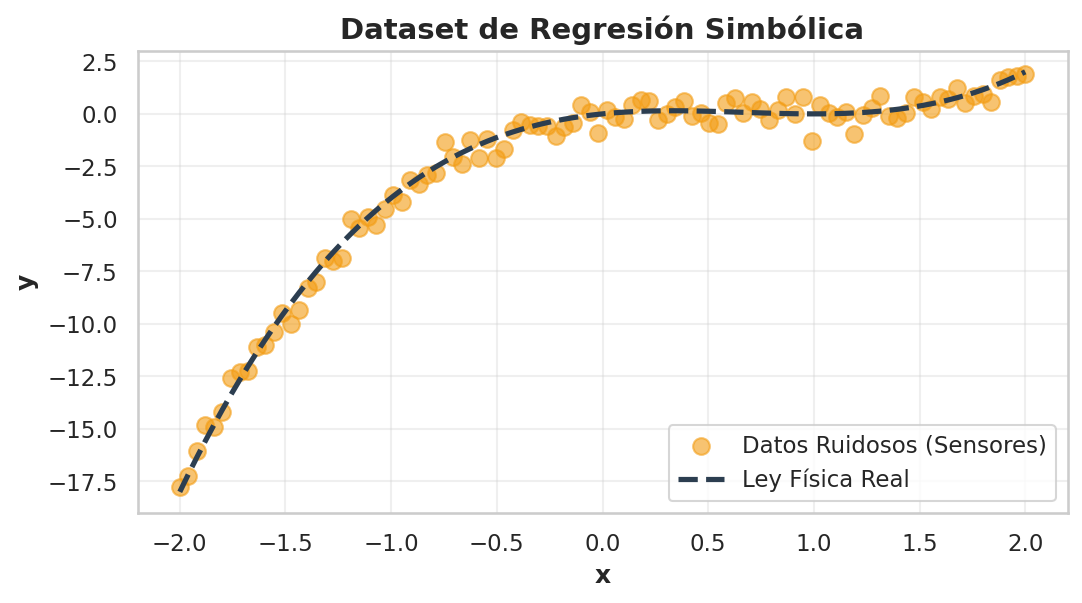

In [6]:
# 1. Generamos el Dataset
X_train = np.linspace(-2, 2, 100)
# y = x^3 - 2x^2 + x + ruido
y_train = X_train**3 - 2*X_train**2 + X_train + np.random.normal(0, 0.5, 100)

plt.figure(figsize=(8, 4))
plt.scatter(X_train, y_train, color='#f39c12', alpha=0.6, label='Datos Ruidosos (Sensores)')
plt.plot(X_train, X_train**3 - 2*X_train**2 + X_train, color='#2c3e50', linestyle='--', label='Ley Física Real')
plt.title("Dataset de Regresión Simbólica")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Ensamblado del Toolbox y Ejecución


In [7]:
# 2. Función de Fitness (MSE + Presión de Parsimonia)
toolbox.register("compile", gp.compile, pset=pset)

def evaluar_simbolica(individuo):
    func = toolbox.compile(expr=individuo)

    try:
        y_pred = np.array([func(x) for x in X_train])
        # Penalizamos si el modelo genera constantes puras o infinitos
        if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
            return (float('inf'),)
        mse = np.mean((y_pred - y_train)**2)

    # Solo capturamos errores matemáticos esperados en GP:
    except (OverflowError, ValueError, ZeroDivisionError):
        return (float('inf'),)

    # Presión de Parsimonia: Penalizamos ligeramente el tamaño del árbol
    # fitness = MSE + (0.01 * cantidad_de_nodos)
    penalizacion = 0.01 * len(individuo)

    return (mse + penalizacion,)

toolbox.register("evaluate", evaluar_simbolica)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

> ⚠️ **CRITERIO DE INGENIERÍA**: Capturar Errores Específicos  
No conviene usar `except Exception`: si hay un error de sintaxis en el código,
el `try-except` genérico lo silencia y te devuelve fitness infinito,
haciendo creer que el GA no converge, cuando en realidad el código está roto.

In [8]:
# 3. Operadores y Control de Bloat
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

# Límite estático: Ningún árbol puede superar la profundidad de 10
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=10))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=10))

# 4. Ejecución del Algoritmo
random.seed(SEED)
pop = toolbox.population(n=300)
hof = tools.HallOfFame(1)

stats_fit = tools.Statistics(lambda ind: ind.fitness.values[0])
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("min", np.min)
mstats.register("mean", np.mean)

print("Iniciando Regresión Simbólica...")
pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.2, ngen=40,
                               stats=mstats, halloffame=hof, verbose=False)

mejor_ecuacion = hof[0]
print(f"\nEvolución Terminada.")
print(f"Mejor Ecuación Encontrada (Formato Lisp):")
print(str(mejor_ecuacion))
print(f"Nodos: {len(mejor_ecuacion)} | Profundidad: {mejor_ecuacion.height}")

Iniciando Regresión Simbólica...

Evolución Terminada.
Mejor Ecuación Encontrada (Formato Lisp):
sub(mul(add(x, x), protected_div(2.76, sub(-3.72, -0.23))), mul(add(sub(x, sub(mul(x, x), -2.82)), x), x))
Nodos: 21 | Profundidad: 6


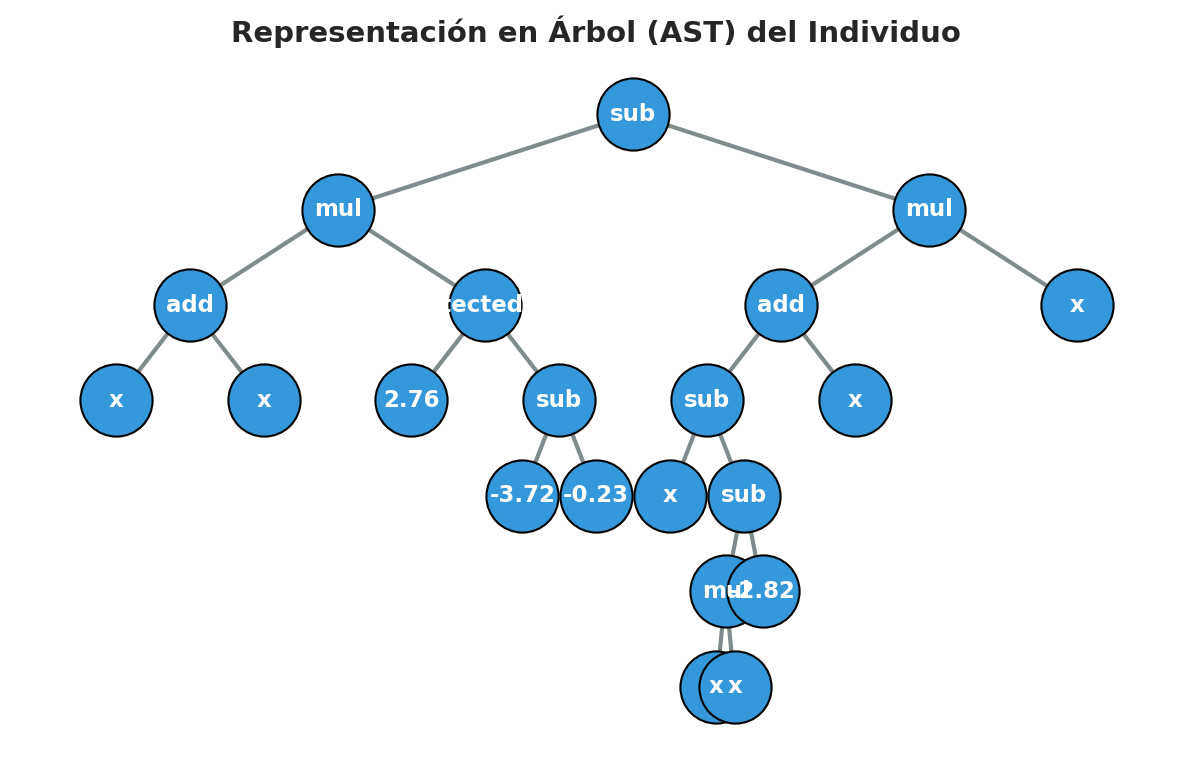

In [9]:
dibujar_arbol_gp(mejor_ecuacion)

La expresión resultante suele ser "fea", va ejemplo para convertirla e incluso simplificarla:

In [10]:
import sympy as sp

mejor_ecuacion = hof[0]
print(f"{'='*60}\nMEJOR EXPRESIÓN ENCONTRADA (LISP)\n{'='*60}")
print(f"  Expresión cruda: {str(mejor_ecuacion)}")
print(f"  Nodos: {len(mejor_ecuacion)} | Profundidad: {mejor_ecuacion.height}")
print(f"  MSE train: {mejor_ecuacion.fitness.values[0]:.6f}\n")

# --- Simplificación Simbólica con SymPy ---
# Mapeamos las funciones de DEAP a funciones de SymPy
x_sym = sp.Symbol('x')
mapeo_sympy = {
    'add': lambda a, b: a + b,
    'sub': lambda a, b: a - b,
    'mul': lambda a, b: a * b,
    'protected_div': lambda a, b: a / b, # Asumimos división ideal para simplificar
    'protected_log': lambda a: sp.log(a),
    'sin': sp.sin,
    'cos': sp.cos,
    'x': x_sym
}

try:
    # Evaluamos el string Lisp usando nuestro diccionario de mapeo
    expr_sympy = eval(str(mejor_ecuacion), {"__builtins__": None}, mapeo_sympy)
    expr_simplificada = sp.simplify(expr_sympy)

    print(f"{'='*60}\nECUACIÓN MATEMÁTICA SIMPLIFICADA\n{'='*60}")
    print(f"  f(x) = {expr_simplificada}")

    # Exportamos el modelo (Guardamos el string de la ecuación)
    with open("mejor_modelo_gp.txt", "w") as f:
        f.write(str(expr_simplificada))
    print("\nModelo exportado exitosamente a 'mejor_modelo_gp.txt'")

except Exception as e:
    print(f"No se pudo simplificar con SymPy: {e}")

MEJOR EXPRESIÓN ENCONTRADA (LISP)
  Expresión cruda: sub(mul(add(x, x), protected_div(2.76, sub(-3.72, -0.23))), mul(add(sub(x, sub(mul(x, x), -2.82)), x), x))
  Nodos: 21 | Profundidad: 6
  MSE train: 0.482917

ECUACIÓN MATEMÁTICA SIMPLIFICADA
  f(x) = x*(x**2 - 2*x + 1.23833810888252)

Modelo exportado exitosamente a 'mejor_modelo_gp.txt'


In [11]:
expr_simplificada

x*(x**2 - 2*x + 1.23833810888252)

Ahora sí! La "pinta" es otra, resta ver si sirve o si convergió a cualquier cosa.

### Análisis de Resultados



Compilamos la mejor ecuación encontrada por el GP y la superponemos sobre nuestros datos para ver qué tan bien logró modelar la realidad.



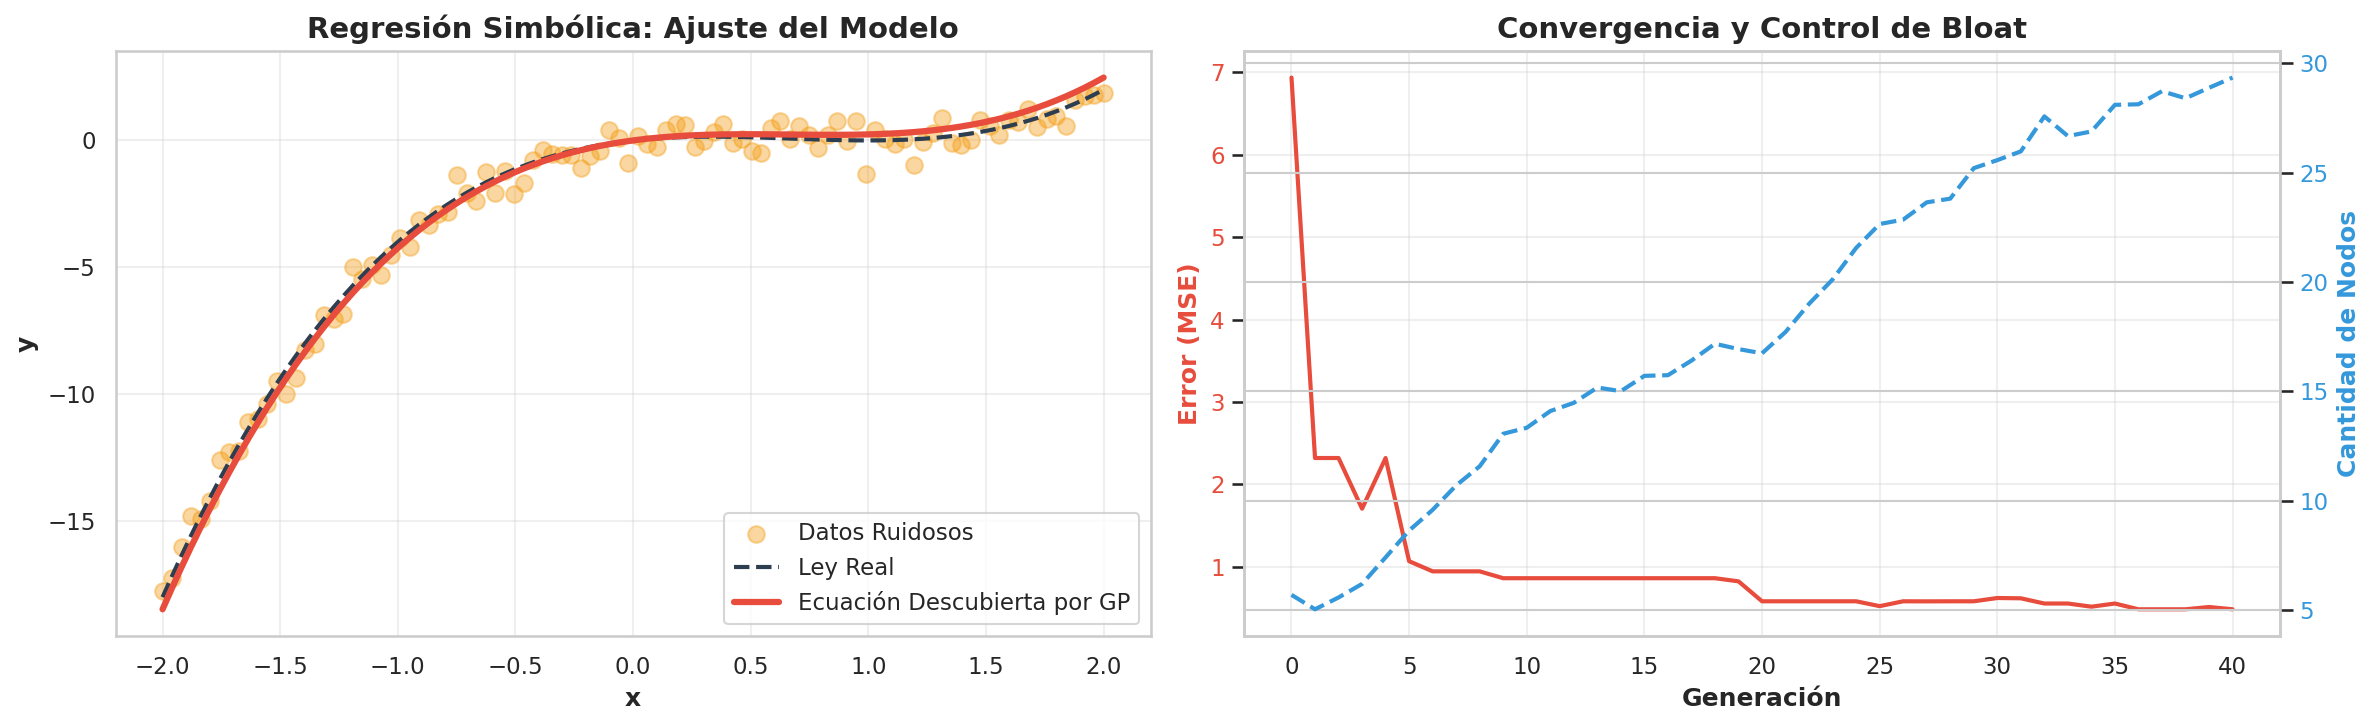

In [12]:
# Compilamos el mejor individuo
mejor_func = toolbox.compile(expr=mejor_ecuacion)
y_pred_gp = np.array([mejor_func(x) for x in X_train])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Ajuste de la Curva
ax1.scatter(X_train, y_train, color='#f39c12', alpha=0.4, label='Datos Ruidosos')
ax1.plot(X_train, X_train**3 - 2*X_train**2 + X_train, color='#2c3e50', linestyle='--', lw=2, label='Ley Real')
ax1.plot(X_train, y_pred_gp, color='#e74c3c', lw=3, label='Ecuación Descubierta por GP')
ax1.set_title("Regresión Simbólica: Ajuste del Modelo")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Convergencia del Error y Tamaño
gen = log.select("gen")
fit_min = log.chapters["fitness"].select("min")
size_mean = log.chapters["size"].select("mean")

ax2.plot(gen, fit_min, color='#e74c3c', lw=2, label='Mejor Error (MSE)')
ax2.set_ylabel("Error (MSE)", color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_xlabel("Generación")

ax3 = ax2.twinx()
ax3.plot(gen, size_mean, color='#3498db', lw=2, linestyle='--', label='Tamaño Medio del Árbol')
ax3.set_ylabel("Cantidad de Nodos", color='#3498db')
ax3.tick_params(axis='y', labelcolor='#3498db')

ax2.set_title("Convergencia y Control de Bloat")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Comparativa: Regresión Polinómica Clásica (Grado 3)

Pequeña gráfica para comparar resultados con métodos clásicos. Utilizo un `polyfit`, notar que para ello... es necesario saber que estamos abordando un polinomio de grado 3.

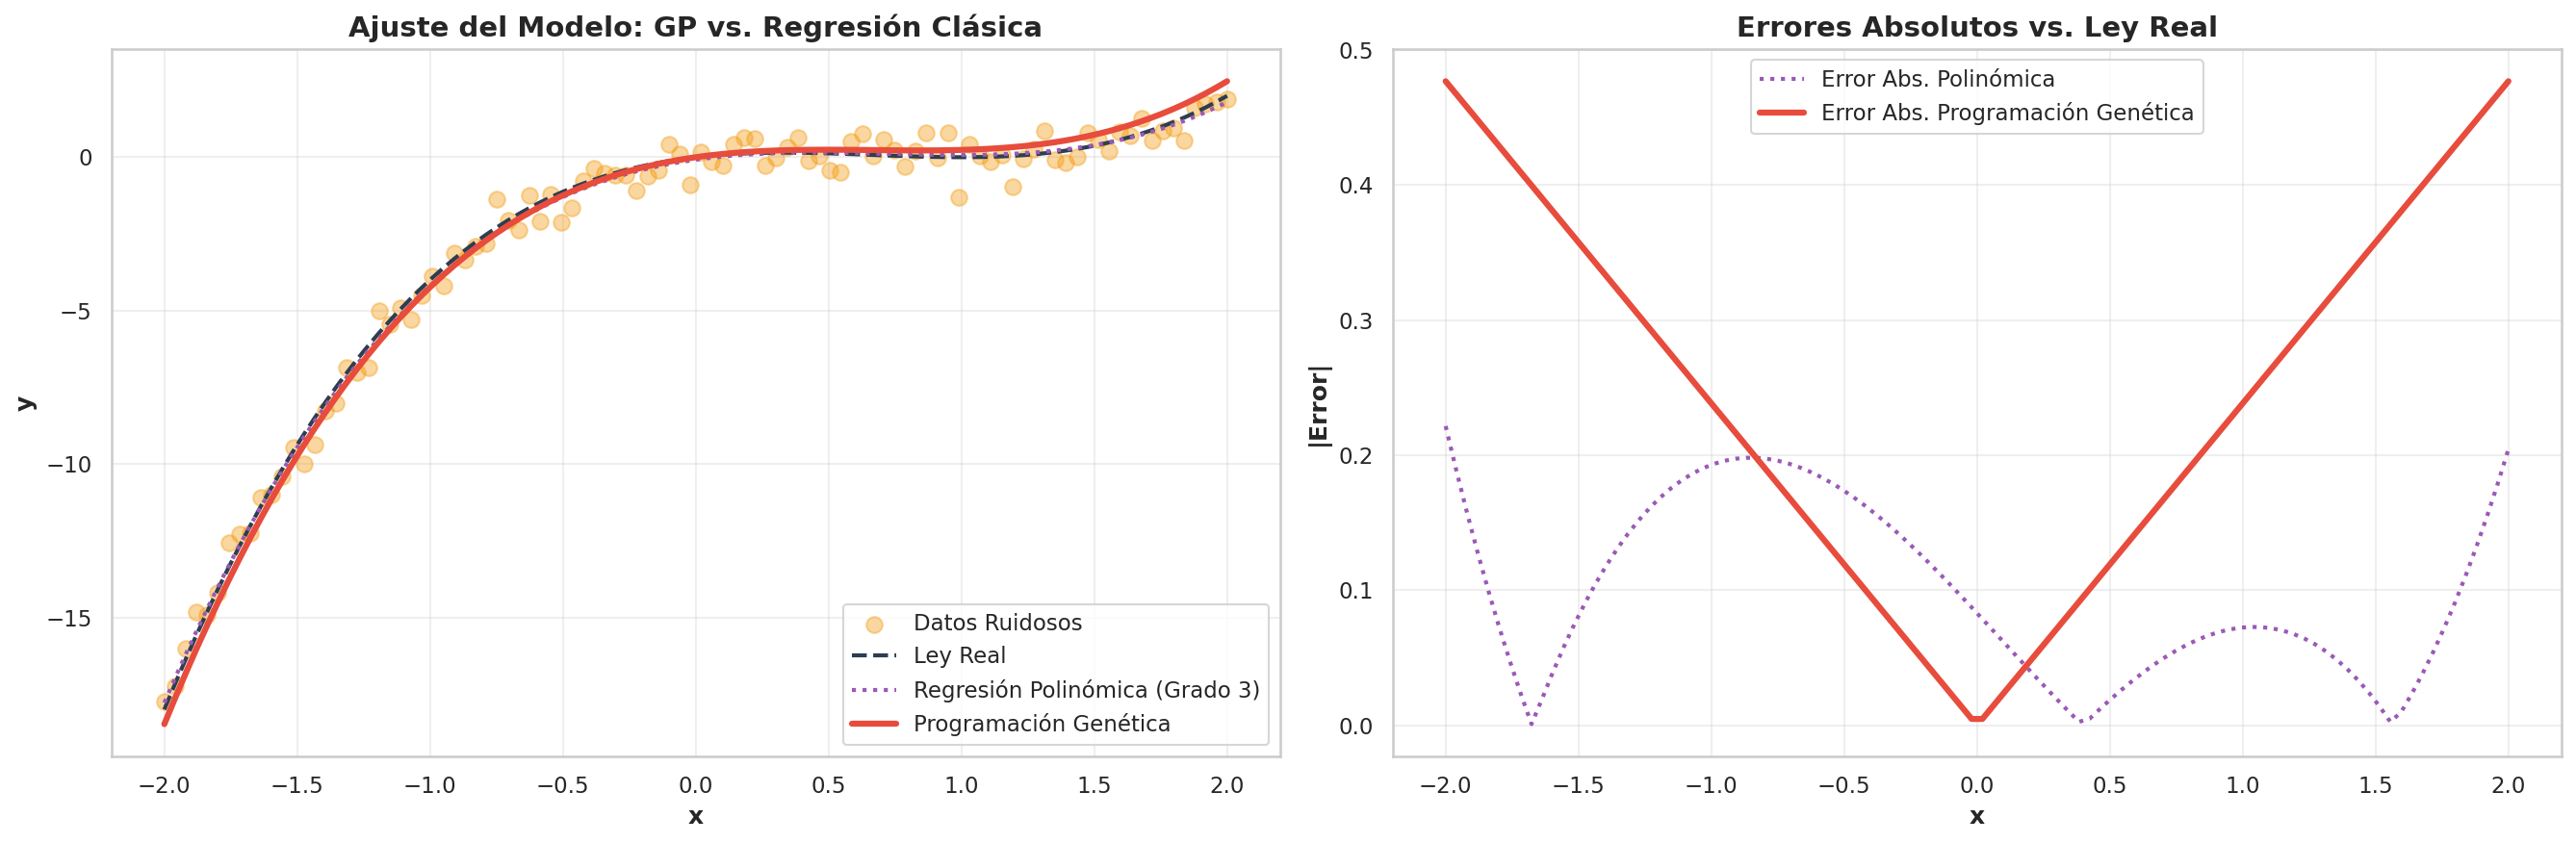

In [13]:
# Regresión Polinómica Clásica (Grado 3)
coefs = np.polyfit(X_train, y_train, 3)
poly_model = np.poly1d(coefs)
y_pred_poly = poly_model(X_train)

# Calculamos los valores reales de la función subyacente
y_real = X_train**3 - 2*X_train**2 + X_train

# Calculamos los errores absolutos de cada modelo respecto a la Ley Real
error_gp = np.abs(y_pred_gp - y_real)
error_poly = np.abs(y_pred_poly - y_real)

# Creamos una figura con dos subplots para la comparativa
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Ajuste de la Curva (GP vs Polyfit)
axs[0].scatter(X_train, y_train, color='#f39c12', alpha=0.4, label='Datos Ruidosos')
axs[0].plot(X_train, y_real, color='#2c3e50', linestyle='--', lw=2, label='Ley Real')
axs[0].plot(X_train, y_pred_poly, color='#9b59b6', lw=2, linestyle=':', label='Regresión Polinómica (Grado 3)')
axs[0].plot(X_train, y_pred_gp, color='#e74c3c', lw=3, label='Programación Genética')
axs[0].set_title("Ajuste del Modelo: GP vs. Regresión Clásica")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Subplot 2: Errores Absolutos
axs[1].plot(X_train, error_poly, color='#9b59b6', lw=2, linestyle=':', label='Error Abs. Polinómica')
axs[1].plot(X_train, error_gp, color='#e74c3c', lw=3, label='Error Abs. Programación Genética')
axs[1].set_title("Errores Absolutos vs. Ley Real")
axs[1].set_xlabel("x")
axs[1].set_ylabel("|Error|")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Discusión de Ingeniería


1. **GP vs. Regresión Polinómica:** Observar la gráfica izquierda. La regresión polinómica clásica (`np.polyfit`) ajusta casi perfectamente porque *nosotros le dijimos que buscara un polinomio de grado 3*. El GP, en cambio, **no sabía nada sobre la forma de la ecuación**. Descubrió la estructura cúbica por sí solo a partir de los datos crudos.
2. **Diagnóstico del Bloat (Gráfica Derecha - figura de arriba, no la última):** Observar cómo en las primeras 5 generaciones, el error (rojo) cae drásticamente, mientras que el tamaño del árbol (azul) crece. Llega un punto donde el error se estanca, pero el árbol intenta seguir creciendo añadiendo "código basura" para sobreajustar el ruido. Gracias a nuestra **Presión de Parsimonia** y al límite estático de profundidad, la línea azul se estabiliza. Sin estas protecciones, la línea azul habría crecido exponencialmente hasta agotar la RAM.
3. **Importancia de SymPy:** El árbol Lisp crudo es incomprensible para un cliente, o incluso nosotros mismos. El GP encuentra formas matemáticamente equivalentes (o aproximaciones de Taylor) utilizando los bloques que le dimos. Al usar `sympy.simplify`, transformamos un árbol gigante lleno de redundancias en una ecuación matemática limpia y lista para producción.

## Conexiones y Próximos Pasos


La Programación Genética es la forma más pura de Inteligencia Artificial: una máquina escribiendo código para resolver un problema.

Usamos GP para descubrir una ley física 1D, pero sus aplicaciones industriales son múltiples, van algunos ejemplos:

*   **Controladores Evolutivos:** En lugar de sintonizar manualmente un PID clásico, GP puede evolucionar la ecuación de control completa para un dron, un brazo robótico o un vehículo autónomo, descubriendo comportamientos no intuitivos pero altamente eficientes.
*   **Diseño de Circuitos y Antenas:** GP ha sido utilizado para diseñar topologías de circuitos analógicos y antenas que superan diseños humanos (varios de ellos patentados por la NASA). El algoritmo explora configuraciones que un ingeniero humano difícilmente consideraría.
*  **Descubrimiento Científico y Regresión Simbólica:** GP ha redescubierto leyes físicas conocidas (Kepler, Navier-Stokes aproximadas) y ha propuesto nuevas relaciones en biomedicina, finanzas y dinámica de fluidos a partir de datos experimentales ruidosos.
*  **Evolución de Estrategias en Juegos y Robótica:** Evoluciona comportamientos completos de agentes (bots de juegos, locomoción para robots cuadrúpedos) sin necesidad de programarlos explícitamente.
*  **Optimización de Estructuras y Diseño Generativo:** En ingeniería mecánica y aeroespacial, GP evoluciona topologías de estructuras (ala de avión, piezas para impresión en 3D) maximizando resistencia y minimizando peso bajo múltiples restricciones físicas.
*   **Feature Engineering Automatizado:** Dado un dataset con decenas de columnas, GP genera combinaciones matemáticas complejas (`col_1 / sqrt(col_2 + col_3)` o `log(col_5) * sin(col_7)`) que maximizan el poder predictivo de modelos posteriores. Es una de las aplicaciones más valiosas en pipelines de Machine Learning industrial.


A esto último se le llama **Genetic Feature Construction**, y lo abordamos en los Casos de Estudio del capítulo.

Pero antes, debemos resolver otro problema fundamental: ¿Qué pasa si nuestro problema tiene múltiples objetivos a optimizar? Hasta ahora, utilizamos artilugios y unimos múltiples objetivos como una única salida de la función de fitness. Por ejemplo, incluso en este notebook, abordamos el problema del *Bloat* y lo resolvimos sumando el tamaño del árbol al error (una suma ponderada). En pocas palabras, sumamos peras con manzanas (Error + Tamaño). ¿Qué pasa si en lugar de sumarlos, los tratamos como dos objetivos independientes en conflicto?

- ➡️ **Siguiente:** [Optimización Multiobjetivo y Frentes de Pareto (NSGA-II)](08_optimizacion_multiobjetivo_nsga2.ipynb)
- 🔄 **Relacionado:** [Feature Engineering Automatizado e Interpretable con Programación Genética](./casos_estudio/gp_feature_engineering.ipynb)



## Referencias


### Obras Fundacionales

1. **Koza, J. R. (1992)**. *Genetic Programming: On the Programming of Computers by Means of Natural Selection*. MIT Press.  
   (**El libro que fundó el campo** — lectura obligatoria para entender la visión original).

2. **Poli, R., Langdon, W. B., & McPhee, N. F. (2008)**. *A Field Guide to Genetic Programming*. Lulu.com.  
   (**Guía práctica gratuita y excelente** — altamente recomendada).


### Recursos Prácticos

- **DEAP Documentation** — Ejemplos avanzados de GP y regresión simbólica. Van algunos: [Genetic Programming](https://deap.readthedocs.io/en/master/tutorials/advanced/gp.html) y [Symbolic Regression Problem](https://deap.readthedocs.io/en/master/examples/gp_symbreg.html)
---


## Entorno de Ejecución


In [14]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
deap,1.4
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
